---
title: "POD gallery — plotting P_d(·) for every detection model"
---

# POD gallery

Ten GLM-style probability-of-detection curves, all living in `methane_pod.pod_functions`. Every module follows the same interface: an `equinox.Module` with a `__call__(Q, …)` method and a `sample_priors()` factory. The progression goes from the **simplest logistic** (Q-only sigmoid) through **multi-covariate additive GLMs** (wind, pixel size, albedo, zenith) to **varying-coefficient models** (environment modulates the sigmoid slope) and alternative links (probit, cloglog).

This notebook ignores the prior-sampling side and focuses on the shapes of the deterministic curves.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from methane_pod import pod_functions as pf

# Flux grid — log-spaced so the sigmoid transition is visible
Q = jnp.logspace(0, 5, 600)
Q_log = jnp.log10(Q)

# Default environmental conditions for multi-covariate models
U_DEFAULT = jnp.full(Q.shape, 5.0)   # m/s
P_DEFAULT = jnp.full(Q.shape, 100.0)  # m
ALB_DEFAULT = jnp.full(Q.shape, 0.5)
COS_DEFAULT = jnp.full(Q.shape, 0.8)
SIGMA_DEFAULT = jnp.full(Q.shape, 0.1)
NBANDS_DEFAULT = jnp.full(Q.shape, 100.0)
RES_DEFAULT = jnp.full(Q.shape, 2.0)

## 1. Logistic on raw Q

The textbook single-covariate detection curve: $P_d(Q) = \sigma(k(Q - Q_{50}))$. The two parameters are the flux at 50 % detection and the sigmoid steepness. Different satellites sit at wildly different $Q_{50}$ — GHGSat ≈ 100, MethaneSAT ≈ 200, TROPOMI ≈ 3000 kg/hr.

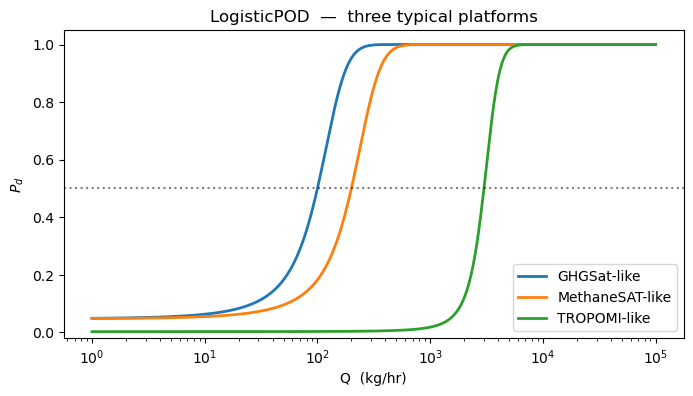

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, Q50, k in [("GHGSat-like", 100.0, 0.03),
                      ("MethaneSAT-like", 200.0, 0.015),
                      ("TROPOMI-like", 3000.0, 0.002)]:
    model = pf.LogisticPOD(Q_50=Q50, k=k)
    ax.semilogx(Q, model(Q), lw=2, label=label)

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("LogisticPOD  —  three typical platforms")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
ax.set_ylim(-0.02, 1.05)
plt.show()

## 2. Log-logistic and concentration-proxy GLMs

The log-logistic form $\text{logit}(P_d) = \beta_0 + \beta_1 \ln Q$ is what you get when you fit the POD to heavily-skewed data — it's equivalent to a lognormal CDF shape. The concentration-proxy GLM replaces $\ln Q$ with $\ln Q/(U \cdot p)$, which is the physical column enhancement a satellite actually sees.

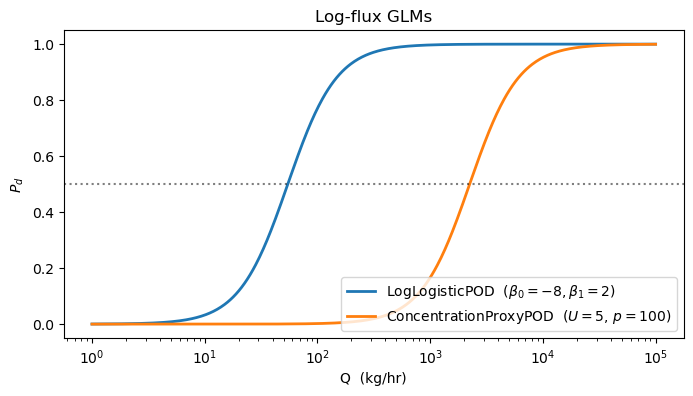

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
loglog = pf.LogLogisticPOD(beta_0=-8.0, beta_1=2.0)
ax.semilogx(Q, loglog(Q), lw=2, label="LogLogisticPOD  $(\\beta_0=-8, \\beta_1=2)$")

conc = pf.ConcentrationProxyPOD(beta_0=-3.0, beta_1=2.0)
ax.semilogx(Q, conc(Q, U_DEFAULT, P_DEFAULT), lw=2,
            label="ConcentrationProxyPOD  $(U=5,\\, p=100)$")

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
ax.set_title("Log-flux GLMs")
plt.show()

## 3. The effect of environmental covariates

For the `AdditiveMultiCovariatePOD`, each covariate has its own sensitivity. Holding Q fixed and sweeping one covariate at a time shows the direction and magnitude of each effect. Physical expectations: β_U < 0 (wind dilutes), β_p < 0 (pixel size dilutes), β_A > 0 (brighter surface), β_θ > 0 (higher sun).

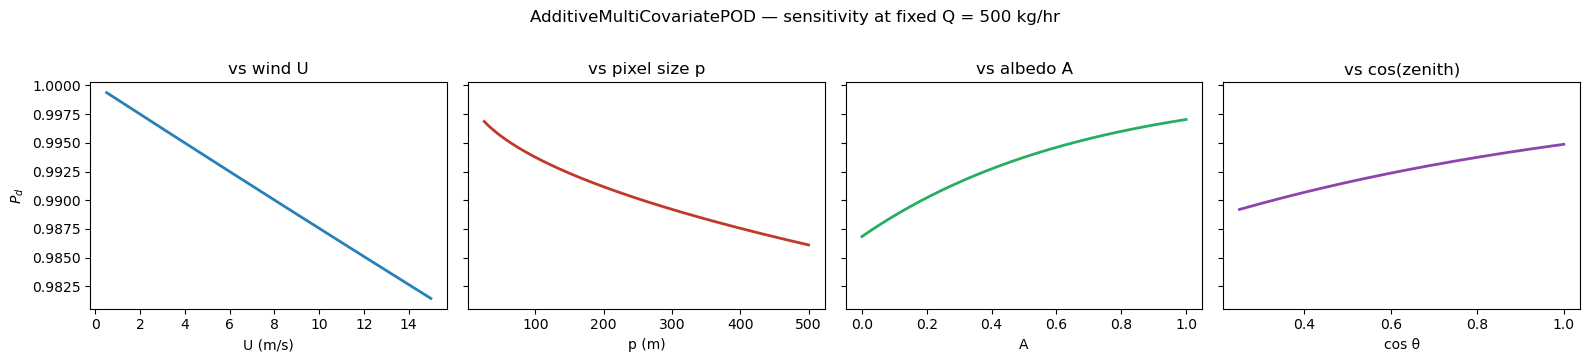

In [4]:
add_model = pf.AdditiveMultiCovariatePOD(
    beta_0=-5.0, beta_Q=2.0, beta_U=-1.0, beta_p=-0.5, beta_A=1.5, beta_theta=1.0
)

# Sweep each covariate while holding the others fixed, at a fixed Q = 500 kg/hr
Q_fix = jnp.full(200, 500.0)
U_sweep = jnp.linspace(0.5, 15.0, 200)
P_sweep = jnp.linspace(25.0, 500.0, 200)
A_sweep = jnp.linspace(0.0, 1.0, 200)
C_sweep = jnp.linspace(0.25, 1.0, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

def with_sweep(u=None, p=None, a=None, c=None):
    u_ = u if u is not None else jnp.full(200, 5.0)
    p_ = p if p is not None else jnp.full(200, 100.0)
    a_ = a if a is not None else jnp.full(200, 0.5)
    c_ = c if c is not None else jnp.full(200, 0.8)
    return add_model(Q_fix, u_, p_, a_, c_)

axes[0].plot(U_sweep, with_sweep(u=U_sweep), color="#2980b9", lw=2)
axes[0].set_title("vs wind U"); axes[0].set_xlabel("U (m/s)"); axes[0].set_ylabel("$P_d$")

axes[1].plot(P_sweep, with_sweep(p=P_sweep), color="#c0392b", lw=2)
axes[1].set_title("vs pixel size p"); axes[1].set_xlabel("p (m)")

axes[2].plot(A_sweep, with_sweep(a=A_sweep), color="#27ae60", lw=2)
axes[2].set_title("vs albedo A"); axes[2].set_xlabel("A")

axes[3].plot(C_sweep, with_sweep(c=C_sweep), color="#8e44ad", lw=2)
axes[3].set_title("vs cos(zenith)"); axes[3].set_xlabel("cos θ")

fig.suptitle("AdditiveMultiCovariatePOD — sensitivity at fixed Q = 500 kg/hr", y=1.02)
fig.tight_layout(); plt.show()

## 4. Varying-coefficient POD: environment modulates the *slope*

The additive model shifts the sigmoid horizontally. The varying-coefficient model makes the sigmoid **steeper** under favourable conditions (high albedo, overhead sun). This is the physically correct picture for a matched-filter retrieval: better radiometric conditions don't change the threshold much, but they do sharpen the discrimination.

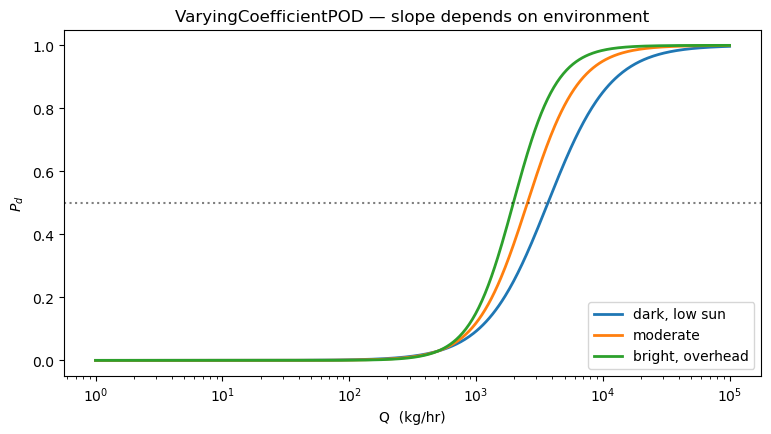

In [5]:
vc = pf.VaryingCoefficientPOD(
    beta_0=-3.5, gamma_base=1.5, gamma_albedo=1.0, gamma_cos_theta=0.5
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for albedo, cos_th, label in [
    (0.1, 0.3, "dark, low sun"),
    (0.3, 0.7, "moderate"),
    (0.6, 0.9, "bright, overhead"),
]:
    A = jnp.full(Q.shape, albedo)
    C = jnp.full(Q.shape, cos_th)
    ax.semilogx(Q, vc(Q, U_DEFAULT, P_DEFAULT, A, C), lw=2, label=label)

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("VaryingCoefficientPOD — slope depends on environment")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
plt.show()

## 5. Radiometric (SNR) and spectral-aware GLMs

Two models parameterised in terms of first-principles instrument physics. `SNRBasedPOD` takes signal-to-noise directly as its predictor. `SpectralAwarePOD` adds the number of spectral channels in the CH₄ absorption window and the spectral resolution Δλ — hyperspectral instruments with more bands dominate multispectral ones at low Q.

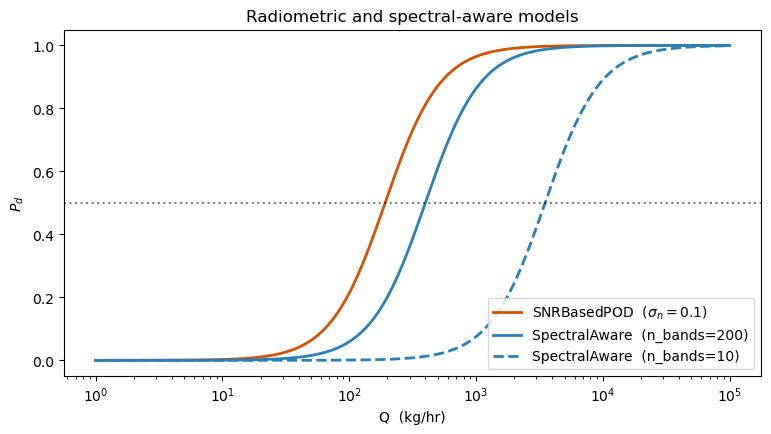

In [6]:
snr = pf.SNRBasedPOD(beta_0=-2.0, beta_1=2.0)
spec_hyper = pf.SpectralAwarePOD(
    beta_0=-5.0, beta_proxy=2.0, beta_n_bands=1.0,
    beta_spectral_res=-0.5, beta_albedo=1.0,
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(Q, snr(Q, U_DEFAULT, P_DEFAULT, ALB_DEFAULT, SIGMA_DEFAULT),
            color="#d35400", lw=2, label="SNRBasedPOD  ($\\sigma_n=0.1$)")

# Compare hyperspectral (n=200) vs multispectral (n=10)
ax.semilogx(Q, spec_hyper(Q, U_DEFAULT, P_DEFAULT, ALB_DEFAULT,
                          jnp.full(Q.shape, 200.0), jnp.full(Q.shape, 2.0)),
            color="#2980b9", lw=2, label="SpectralAware  (n_bands=200)")
ax.semilogx(Q, spec_hyper(Q, U_DEFAULT, P_DEFAULT, ALB_DEFAULT,
                          jnp.full(Q.shape, 10.0), jnp.full(Q.shape, 30.0)),
            color="#2980b9", lw=2, ls="--", label="SpectralAware  (n_bands=10)")

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("Radiometric and spectral-aware models")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
plt.show()

## 6. The "kitchen sink" full varying-coefficient model

Both the intercept AND the slope depend on the environment — the most expressive model in the family. Intercept responds to instrument noise (more noise → baseline goes down); slope responds to albedo, cos(zenith), and number of bands (better conditions → steeper curve).

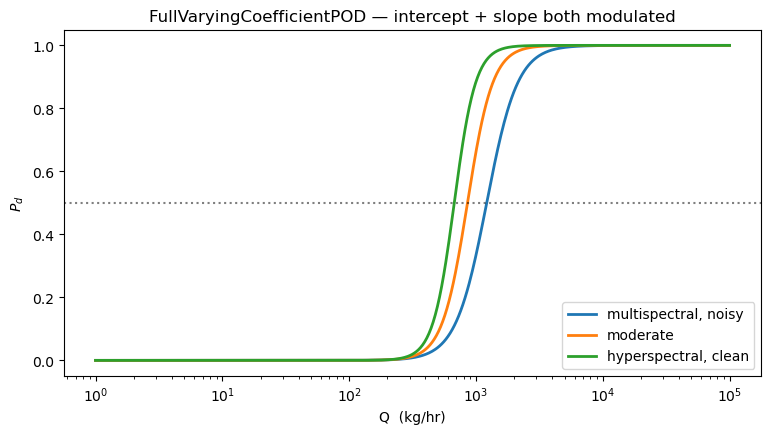

In [7]:
full_vc = pf.FullVaryingCoefficientPOD(
    beta_0_base=-3.5, beta_0_noise=-0.5, gamma_base=1.5,
    gamma_albedo=1.0, gamma_cos_theta=0.5, gamma_n_bands=0.5,
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nbands, sigma_n, label in [
    (10.0, 0.5, "multispectral, noisy"),
    (50.0, 0.1, "moderate"),
    (250.0, 0.02, "hyperspectral, clean"),
]:
    ax.semilogx(
        Q, full_vc(Q, U_DEFAULT, P_DEFAULT, ALB_DEFAULT, COS_DEFAULT,
                   jnp.full(Q.shape, nbands), jnp.full(Q.shape, sigma_n)),
        lw=2, label=label,
    )

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("FullVaryingCoefficientPOD — intercept + slope both modulated")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
plt.show()

## 7. Alternative link functions: probit and cloglog

Logistic is the default but not the only choice. **Probit** arises when the latent detection signal is Gaussian; the curve is nearly identical to logistic but with slightly thinner tails. **Cloglog** is asymmetric — it approaches 1 much faster than it departs 0 — and is the natural link when detection is a "first-exceedance" event.

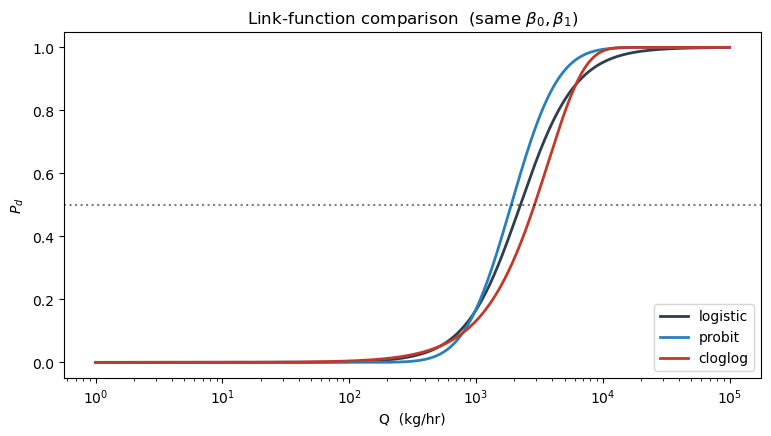

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
probit = pf.ProbitPOD(beta_0=-2.0, beta_1=1.5)
clog = pf.CloglogPOD(beta_0=-3.0, beta_1=1.5)
conc = pf.ConcentrationProxyPOD(beta_0=-3.0, beta_1=2.0)

ax.semilogx(Q, conc(Q, U_DEFAULT, P_DEFAULT), lw=2, label="logistic", color="#2c3e50")
ax.semilogx(Q, probit(Q, U_DEFAULT, P_DEFAULT), lw=2, label="probit", color="#2980b9")
ax.semilogx(Q, clog(Q, U_DEFAULT, P_DEFAULT), lw=2, label="cloglog", color="#c0392b")

ax.set_xlabel("Q  (kg/hr)"); ax.set_ylabel("$P_d$")
ax.set_title("Link-function comparison  (same $\\beta_0, \\beta_1$)")
ax.axhline(0.5, color="k", ls=":", alpha=0.5)
ax.legend(loc="lower right")
plt.show()

## Registry roll-call

In [9]:
print(f"Registered POD modules: {len(pf.POD_REGISTRY)}")
for key, cls in pf.POD_REGISTRY.items():
    print(f"  {key:<22s} -> {cls.__name__}")

Registered POD modules: 10
  logistic               -> LogisticPOD
  log_logistic           -> LogLogisticPOD
  concentration_proxy    -> ConcentrationProxyPOD
  additive_multi         -> AdditiveMultiCovariatePOD
  varying_coefficient    -> VaryingCoefficientPOD
  snr_based              -> SNRBasedPOD
  spectral_aware         -> SpectralAwarePOD
  full_varying           -> FullVaryingCoefficientPOD
  probit                 -> ProbitPOD
  cloglog                -> CloglogPOD
